# Figures for Laurianne's NAMS 2025 presentation

Prepared by: Molly Dougher

Adapted from: Xinhong Liu xliu27@nd.edu

### Import library

In [1]:
from utility import *

future: the set contained only NumericConstant and _PythonCallbackFunctionID,
and provided no meaningful value to clients or walkers.  Users should likely
handle these types in the same manner as immutable Params.  (deprecated in
6.7.2) (called from <frozen importlib._bootstrap>:241)
'_BlockData'.  The class '_BlockData' has been renamed to 'BlockData'.
(deprecated in 6.7.2) (called from /opt/anaconda3/envs/dynamic-
diafiltration/lib/python3.11/site-packages/idaes/core/base/process_base.py:78)
from '_GeneralExpressionData'.  The class '_GeneralExpressionData' has been
renamed to 'ExpressionData'.  (deprecated in 6.7.2) (called from
/opt/anaconda3/envs/dynamic-diafiltration/lib/python3.11/site-
packages/idaes/core/base/var_like_expression.py:31)


# NF90 (DATA1)
## Concentrations: Figure 2C-D

In [2]:
from DATA1_matlab.diafiltration_plots import plot_sim_comparison as plot_sim_comparisonDATA1


Loading data file = DATA1_matlab/data/data_stru-dataset511.12.mat 


Loading data file = DATA1_matlab/data/511.12 concpolar/fit_stru.mat 



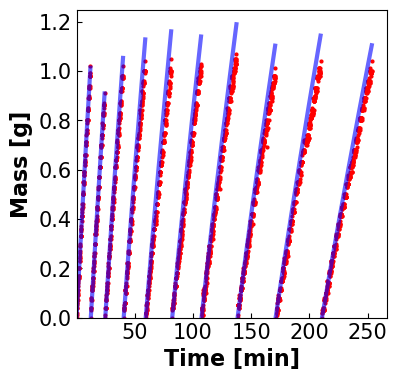

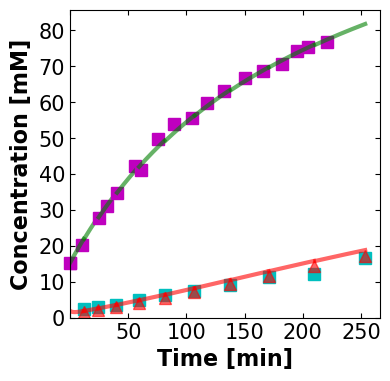

In [3]:
# pull the data from DATA1_matlab/DiafiltrationPaperPlots.ipynb
### Diafiltration
#### M1(conctration polarization, continuous retentate)
# Figure 2, 5, 6, S3, S4
data_stru90 = loadmat('DATA1_matlab/data/data_stru-dataset511.12.mat')['data_stru']
fit_stru90 = loadmat('DATA1_matlab/data/511.12 concpolar/fit_stru.mat')['fit_stru']
plot_sim_comparisonDATA1(data_stru90,fit_stru90,plot_pred=True,cond=True,lg=False)

## Interfacial concentrations

In [4]:
sim_stru90 = fit_stru90["sim_stru"]
        

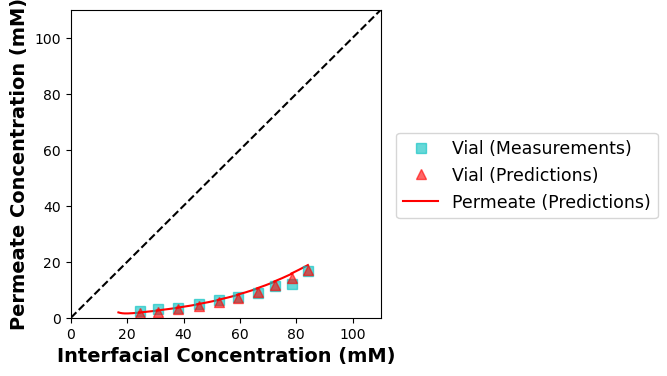

In [5]:
k = 0.23 * (350/60 * np.pi * 2.2860)**0.57 * 1.960e-5**0.67 / (8.927e-3**0.24 * 2.2860**0.43)
cIn_sim = []
cIn_exp = []

fig = plt.figure(figsize=(4,4))

t_delay = float(data_stru90['data_raw'][0]['time'][0])

# TODO: double check logic and exp calc
for vial in range(data_stru90['data_config']['n']):
    # calculate simulated water flux per vial
    vial_dmdt_sim = (sim_stru90[vial]["mV"][-1] - sim_stru90[vial]["mV"][0]) / (sim_stru90[vial]["time"][-1] - sim_stru90[vial]["time"][0])
    vial_water_flux_sim = (1/4.1)*vial_dmdt_sim # cm3/cm2/s
    # calculate simulated cIn
    for value in range(len(sim_stru90[vial]["time"])):
        cIn_sim.append((sim_stru90[vial]['cF'][value]-sim_stru90[vial]['cH'][value])*np.exp(vial_water_flux_sim/k)+sim_stru90[vial]['cH'][value])

    # # calculate exp water flux per vial
    # vial_dmdt_exp = (data_stru90["data_raw"][vial]["mass"][-1] - data_stru90["data_raw"][vial]["mass"][0]) / (data_stru90["data_raw"][vial]["time"][-1] - data_stru90["data_raw"][vial]["time"][0])
    # vial_water_flux_exp = (1/4.1)*vial_dmdt_exp # cm3/cm2/s
    # # calculate exp cIn
    # for value in range(len(data_stru90["data_raw"][vial]["time"])):
    #     cIn_exp.append((data_stru90["data_raw"][vial]['cF_exp'][value]-data_stru90["data_raw"][vial]['cV_avg'][value])*np.exp(vial_water_flux_exp/k)+data_stru90["data_raw"][vial]['cV_avg'][value])
    
    
    # permeate predictions
    plt.plot(cIn_sim,sim_stru90[vial]["cH"],'r-',linewidth=1.5)

    # vial measurements, plot at the last time point
    plt.plot(cIn_sim[-1],data_stru90['data_raw'][vial]['cV_avg'],'cs',markersize=7,alpha=0.6)

    # vial predictions, plot at the last time point
    plt.plot(cIn_sim[-1],sim_stru90[vial]['cV'][-1],'r^',markersize=7, alpha=0.6)
    
    
    cIn_sim = []
    cIn_exp = []


plt.plot([0,110],[0,110],'k--')

plt.xlabel('Interfacial Concentration (mM)',fontsize=14,fontweight='bold')
plt.ylabel('Permeate Concentration (mM)',fontsize=14,fontweight='bold')

# ghost point for legend
plt.plot([],[],'cs',markersize=7,label='Vial (Measurements)', alpha=0.6)
plt.plot([],[],'r^',markersize=7,label='Vial (Predictions)', alpha=0.6)        
plt.plot([],[],'r-',linewidth=1.5,label='Permeate (Predictions)')
plt.legend(fontsize=12.5,loc='best',bbox_to_anchor=(1.05, 0.6),borderaxespad=0)
plt.xlim(left=0,right=110)
plt.ylim(bottom=0,top=110)

plt.show()

## Solute permeability

In [6]:
print(data_stru90["data_raw"][0].keys())
print(data_stru90["data_raw"][0].values())
# print(data_stru90["data_raw"][0]['cF_exp'])
# print(data_stru90["data_raw"][2]['cF_exp'])
# print(data_stru90["data_raw"][2]['cV_avg'])

for vial in range(data_stru90['data_config']['n']):
    list = [x for x in data_stru90["data_raw"][vial]['cF_exp'] if str(x) != 'nan']
    print(list)
    index_list = [data_stru90["data_raw"][vial]['cF_exp'].index(x) for x in data_stru90["data_raw"][vial]['cF_exp'] if str(x) != 'nan']
    print(index_list)

dict_keys(['number', 'time', 'mass', 'cF_exp', 'cV_avg', 'nr'])
dict_values([1, [370, 375, 380, 385, 390, 395, 400, 405, 410, 415, 420, 425, 430, 435, 440, 445, 450, 455, 460, 465, 470, 475, 480, 485, 490, 495, 500, 505, 510, 515, 520, 525, 530, 535, 540, 545, 550, 555, 560, 565, 570, 575, 580, 585, 590, 595, 600, 605, 610, 615, 620, 625, 630, 635, 640, 645, 650, 655, 660, 665, 670, 675, 680, 685, 690, 695, 700, 705, 710, 715, 720, 725, 730, 735, 740, 745, 750, 755, 760, 765, 770, 775, 780, 785, 790, 795, 800, 805, 810, 815, 820, 825, 830, 835, 840, 845, 850, 855, 860, 865, 870, 875, 880, 885, 890, 895, 900, 905, 910, 915, 920, 925, 930, 935, 940, 945, 950, 955, 960, 965, 970, 975, 980, 985, 990, 995, 1000, 1005, 1010, 1015, 1020, 1025, 1030, 1035, 1040, 1045, 1050, 1055, 1060, 1065, 1070, 1075, 1080, 1085], [0.0, 0.01, 0.02, 0.04, 0.04, 0.05, 0.06, 0.06, 0.08, 0.07, 0.07, 0.09, 0.11, 0.09, 0.1, 0.11, 0.13, 0.14, 0.15, 0.16, 0.16, 0.16, 0.17, 0.16, 0.17, 0.17, 0.2, 0.2, 0.2, 0.2, 0.2, 

In [7]:
for vial in range(data_stru90['data_config']['n']):
    list = [x for x in data_stru90["data_raw"][vial]['cF_exp'] if str(x) != 'nan']
    print(list)
    index_list = [data_stru90["data_raw"][vial]['cF_exp'].index(x) for x in data_stru90["data_raw"][vial]['cF_exp'] if str(x) != 'nan']
    print(index_list)

[15.20517956, 20.17925714]
[2, 126]
[]
[]
[27.74228235, 31.0364]
[0, 90]
[34.73451321, 42.10616744]
[0, 180]
[41.21821818, 49.70306667]
[20, 193]
[53.94549091, 55.5364]
[86, 270]
[59.79315676, 63.0364]
[129, 300]
[66.67276364, 68.6614]
[146, 326]
[70.77833548, 74.22284068, 75.4501931]
[134, 284, 404]
[76.72061053]
[116]


In [8]:
print(data_stru90['data_config']["B0"])

0.2952638097170572


(0.0, 110.0)

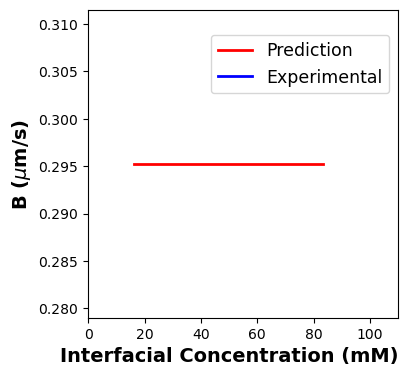

In [9]:
k = 0.23 * (350/60 * np.pi * 2.2860)**0.57 * 1.960e-5**0.67 / (8.927e-3**0.24 * 2.2860**0.43) # cm/s
cIn = []
vial_B90_exp_list = []

fig = plt.figure(figsize=(4,4))

# simulated
cIn0 = 16.17231759780746
cInf = 83.16774021880602
B90 = data_stru90['data_config']["B0"]
plt.plot([cIn0,cInf],[B90,B90],'r-',linewidth=2)

# TODO: double check logic
# # experimental
# for vial in range(data_stru90['data_config']['n']):
#     # calculate experimental water flux per vial
#     vial_dmdt = (data_stru90["data_raw"][vial]["mass"][-1] - data_stru90["data_raw"][vial]["mass"][0]) / (data_stru90["data_raw"][vial]["time"][-1] - data_stru90["data_raw"][vial]["time"][0])
#     # vial_water_flux = 0.146*vial_dmdt # m3/m2/h
#     vial_water_flux = (1/4.1)*vial_dmdt # cm3/cm2/s
#     # calculate cIn at the final time
#     cIn_final = (sim_stru90[vial]['cF'][-1]-sim_stru90[vial]['cH'][-1])*np.exp(vial_water_flux/k)+sim_stru90[vial]['cH'][value])

#     # calculate exp B = (Jw cH)/(cIn-cH) per vial
#     vial_B90_exp = ((vial_water_flux * data_stru90['data_raw'][vial]['cV_avg'])/(np.average(cIn) - data_stru90['data_raw'][vial]['cV_avg']))*10000 #um/s
#     for i in range(len(cIn)):
#         vial_B90_exp_list.append(vial_B90_exp)

#     print(vial_B90_exp)
#     plt.plot(cIn,vial_B90_exp_list,'b-',linewidth=2)

#     cIn = []
#     vial_B90_exp_list = []

plt.xlabel('Interfacial Concentration (mM)',fontsize=14,fontweight='bold',loc='right')
plt.ylabel('B ($\mu$m/s)',fontsize=14,fontweight='bold')

# ghost point for legend    
plt.plot([],[],'r-',linewidth=2,label='Prediction')
plt.plot([],[],'b-',linewidth=2,label='Experimental')
plt.legend(fontsize=12.5,loc='lower right',bbox_to_anchor=(1, 0.7))
plt.xlim(left=0,right=110)

# NF270 (DATA2)
## Concentrations-Lag: Figure 6A-C

### Parameter estimation with a linear B

In [10]:
data_stru270 = loadmat('data_library/data_stru-dataset270511.123.mat')['data_stru']
sim_stru270=[]


Loading data file = data_library/data_stru-dataset270511.123.mat 



###################################################################
Creating and solving the Pyomo model with the following settings: 
mode = Lag
theta = {'Lp': 11, 'beta_c': 15, 'beta_0': 1, 'beta_1': 0.01, 'sigma': 1.0, 'S0': 0}
sim_opt = False
B_form = 1
 


CasADi - 2025-05-06 17:26:47 WARNING("The options 't0', 'tf', 'grid' and 'output_t0' have been deprecated. Set the time grid by proving additional argument to the 'integrator' call instead.") [.../casadi/core/integrator.cpp:496]


Ipopt 3.13.2: linear_solver=ma97
max_iter=3000


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific

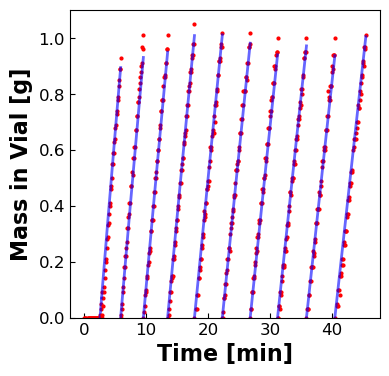

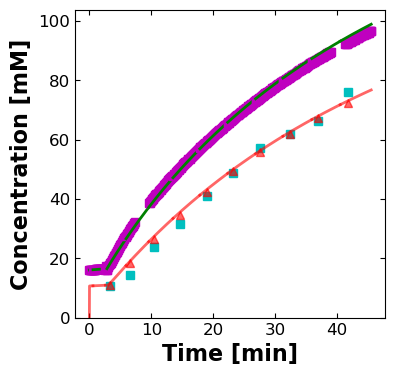

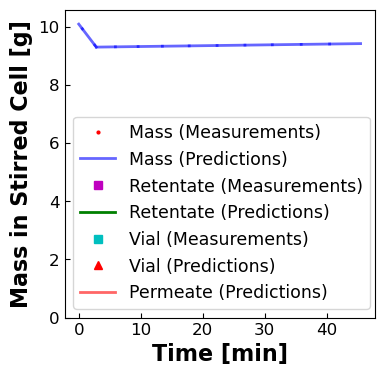

In [11]:
mode = 'Lag'
theta = {'Lp': 11,
  'beta_c': 15,
  'beta_0': 1,
  'beta_1': 0.01,
  'sigma': 1.0,
  'S0': 0}
fit_stru270, sim_stru270, sim_inter270 = solve_model(data_stru270, mode, theta, sim_opt=False, B_form=1,LOUD=False)
plot_sim_comparison(data_stru270,sim_stru270,stirc_mass=True,plot_pred=True,lg=True,LOUD=False)

In [12]:
for i in range(data_stru270['data_config']['n']):
    print(data_stru270['data_raw'][i]['time'])

[100, 105, 110, 115, 120, 125, 130, 135]
[135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190, 195, 200, 205, 210, 215, 220, 225, 230, 235, 240, 245, 250, 255]
[255, 260, 265, 270]
[270, 275, 280, 285, 290, 295, 300, 305, 310, 315, 320, 325, 330, 335, 340, 345, 350, 355, 360, 365, 370, 375, 380, 385, 390, 395, 400, 405, 410, 415, 420, 425, 430, 435, 440, 445, 450, 455]
[455, 460, 465, 470, 475, 480, 485, 490, 495, 500, 505, 510, 515, 520, 525, 530, 535, 540, 545, 550, 555, 560, 565, 570, 575, 580, 585, 590, 595, 600, 605, 610, 615, 620, 625, 630, 635, 640, 645, 650, 655, 660, 665, 670, 675]
[675, 680, 685, 690, 695, 700, 705, 710, 715, 720, 725, 730, 735, 740, 745, 750, 755, 760, 765, 770, 775, 780, 785, 790, 795, 800, 805, 810, 815, 820, 825, 830, 835, 840, 845, 850, 855, 860, 865, 870, 875, 880, 885, 890, 895, 900, 905, 910]
[910, 915, 920, 925, 930, 935, 940, 945, 950, 955, 960, 965, 970, 975, 980, 985, 990, 995, 1000, 1005, 1010, 1015, 1020, 1025, 1030, 1035, 1040, 1045, 105

100


(-0.12916666666666668, 2.8)

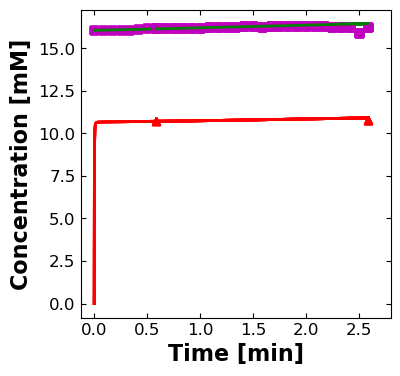

In [13]:
# plot concentration data/prediction comparison
fig,ax = plt.subplots(figsize=(4,4))

t_delay = data_stru270['data_raw'][0]['time'][0]
print(t_delay)
t_start = 0

for i in range(data_stru270['data_config']['n']):
    for pt in range(len((data_stru270['data_raw'][i]['time']))):
        if (data_stru270['data_raw'][i]['time'][pt] <= 200):
            # if type(data_stru270['data_raw'][i]['cV_avg']) != list:
                # plt.plot((float(data_stru270['data_raw'][i]['time'][-1])-t_delay-t_start)/60,
                #             data_stru270['data_raw'][i]['cV_avg'],
                #             'cs',markersize=6)
            # else:
            #     plt.plot([(float(t)-t_delay-t_start)/60 for t in data_stru270['data_raw'][i]['time']],
            #                 data_stru270['data_raw'][i]['cV_avg'],'cs',markersize=6,clip_on=False)
            plt.plot([(float(t)-t_delay-t_start)/60 for t in data_stru270['data_raw'][i]['time']],
                        data_stru270['data_raw'][i]['cF_exp'],'ms',markersize=6,clip_on=False)
            plt.plot([(time-t_start)/60 for time in sim_stru270[i]['time']],
                        sim_stru270[i]['cF'],
                        'g',linewidth=2)
            plt.plot([(time-t_start)/60 for time in sim_stru270[i]['time']],
                        sim_stru270[i]['cH'],
                        'r-',linewidth=2,alpha=.6)
            if type(data_stru270['data_raw'][i]['cV_avg']) != list:
                plt.plot((sim_stru270[i]['time'][-1]-t_start)/60,
                            sim_stru270[i]['cV'][-1],
                            'r^',linewidth=2,alpha=.6)
            else:
                time = data_stru270['data_raw'][i]['time']-t_delay
                index = ~np.isnan(data_stru270['data_raw'][i]['cV_avg'])
                t = [time[i] for i, val in enumerate(index) if val]
                f = interpolate.interp1d(sim_stru270[i]['time'],sim_stru270[i]['cV'], fill_value='extrapolate')  
                plt.plot([(ti-t_start)/60 for ti in t],
                            f(t),
                            'r^',linewidth=2,alpha=.6)
            
plt.xlabel('Time [min]',fontsize=16,fontweight='bold')
plt.ylabel('Concentration [mM]',fontsize=16,fontweight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tick_params(direction="in",top=True, right=True)
plt.xlim(right=2.8)

In [14]:
cV_exp_values = [0,0,0]
for vial_dict in data_stru270["data_raw"]:
    for variable, values in vial_dict.items():
        if variable == 'cV_avg':
            for x in values:
                if str(x) != 'nan':
                    cV_exp_values.append(x)
print(cV_exp_values)
print(len(cV_exp_values))

[0, 0, 0, 10.63030414, 14.22108286, 23.72155353, 31.57139223, 40.92372016, 48.77230198, 57.01986578, 61.91865276, 66.15705841, 75.88025664]
13


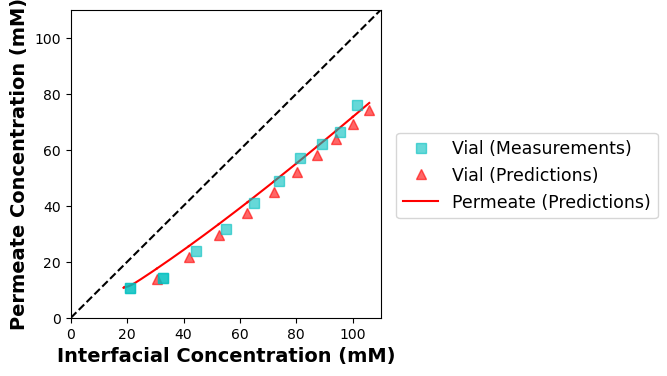

In [15]:
fig = plt.figure(figsize=(4,4))

t_delay = data_stru270['data_raw'][0]['time'][0]

for i in range(data_stru270['data_config']['n']):
    if i != 0:
        # plot permeate predictions
        plt.plot(sim_stru270[i]["cIn"],sim_stru270[i]["cH"],'r-',linewidth=1.5)

        # i=0,1,2 have no vial measurement
        if i >= 3:
            # plot vial predictions, last data entry per vial
            plt.plot(sim_stru270[i]["cIn"][-1],sim_stru270[i]["cV"][-1],'r^',markersize=7,alpha=0.6)
            
        # TODO: double check logic
        for sim_time in sim_stru270[i]["time"]:
            for exp_time in data_stru270["data_raw"][i]["time"]:
                if ((exp_time-t_delay)==round(sim_time,0)):
                # if (abs((exp_time-t_delay)-sim_time)<=0.8):
                    sim_index = sim_stru270[i]["time"].index(sim_time)
                    exp_index = data_stru270["data_raw"][i]["time"].index(exp_time)
                    plt.plot(sim_stru270[i]["cIn"][sim_index],data_stru270['data_raw'][i]['cV_avg'][exp_index],'cs',markersize=7, alpha=0.6)
        
        # i=0,1,2 have no vial measurement
        # if i >= 3:
        # if cV_exp_values[i] != 0:
        #     # vial measurements, last data entry per vial
        #     plt.plot(sim_stru270[i]["cIn"][-1], cV_exp_values[i],'cs',markersize=7, alpha=0.6)
        

plt.plot([0,110],[0,110],'k--')

plt.xlabel('Interfacial Concentration (mM)',fontsize=14,fontweight='bold')
plt.ylabel('Permeate Concentration (mM)',fontsize=14,fontweight='bold')

# ghost point for legend
plt.plot([],[],'cs',markersize=7,label='Vial (Measurements)',alpha=0.6)
plt.plot([],[],'r^',markersize=7,label='Vial (Predictions)',alpha=0.6)        
plt.plot([],[],'r-',linewidth=1.5,label='Permeate (Predictions)')
plt.legend(fontsize=12.5,loc='best',bbox_to_anchor=(1.05, 0.6),borderaxespad=0)
plt.xlim(left=0,right=110)
plt.ylim(bottom=0,top=110)

plt.show()

## Solute Permeability



(0.0, 110.0)

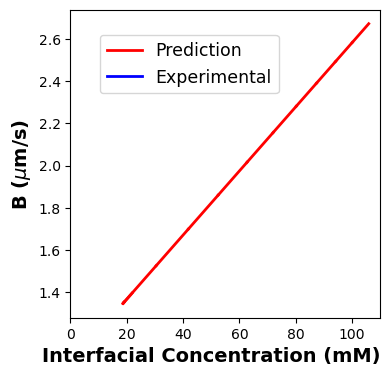

In [16]:
fig = plt.figure(figsize=(4,4))

for i in range(data_stru270['data_config']['n']):
        plt.plot(sim_stru270[i]["cIn"],sim_stru270[i]["B"],'r-',linewidth=2)

plt.xlabel('Interfacial Concentration (mM)',fontsize=14,fontweight='bold',loc='right')
plt.ylabel('B ($\mu$m/s)',fontsize=14,fontweight='bold')
plt.xlim(left=0,right=110)

# ghost point for legend    
plt.plot([],[],'r-',linewidth=2,label='Prediction')
plt.plot([],[],'b-',linewidth=2,label='Experimental')
plt.legend(fontsize=12.5,loc='lower right',bbox_to_anchor=(0.7, 0.7))
plt.xlim(left=0,right=110)

# Combined plots for NF90/NF270
## Concentrations

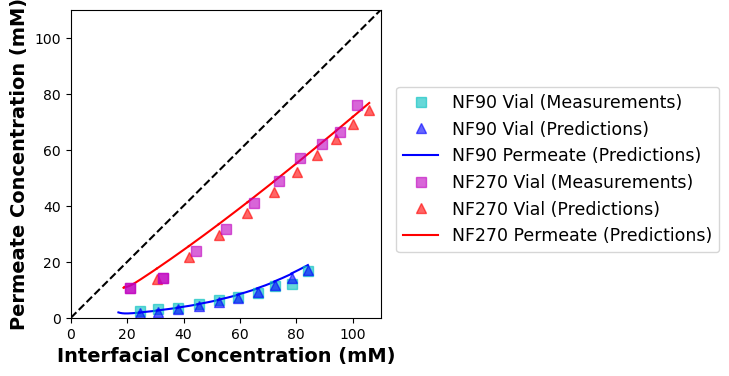

In [24]:
fig = plt.figure(figsize=(4,4))

#-------------------------------------------------------------------------------------------------------------------------------
# NF 90
k = 0.23 * (350/60 * np.pi * 2.2860)**0.57 * 1.960e-5**0.67 / (8.927e-3**0.24 * 2.2860**0.43)
cIn_sim = []
cIn_exp = []

for vial in range(data_stru90['data_config']['n']):
    # calculate simulated water flux per vial
    vial_dmdt_sim = (sim_stru90[vial]["mV"][-1] - sim_stru90[vial]["mV"][0]) / (sim_stru90[vial]["time"][-1] - sim_stru90[vial]["time"][0])
    vial_water_flux_sim = (1/4.1)*vial_dmdt_sim # cm3/cm2/s
    # calculate simulated cIn
    for value in range(len(sim_stru90[vial]["time"])):
        cIn_sim.append((sim_stru90[vial]['cF'][value]-sim_stru90[vial]['cH'][value])*np.exp(vial_water_flux_sim/k)+sim_stru90[vial]['cH'][value])

    # # calculate exp water flux per vial
    # vial_dmdt_exp = (data_stru90["data_raw"][vial]["mass"][-1] - data_stru90["data_raw"][vial]["mass"][0]) / (data_stru90["data_raw"][vial]["time"][-1] - data_stru90["data_raw"][vial]["time"][0])
    # vial_water_flux_exp = (1/4.1)*vial_dmdt_exp # cm3/cm2/s
    # # calculate exp cIn
    # for value in range(len(data_stru90["data_raw"][vial]["time"])):
    #     cIn_exp.append((data_stru90["data_raw"][vial]['cF_exp'][value]-data_stru90["data_raw"][vial]['cV_avg'][value])*np.exp(vial_water_flux_exp/k)+data_stru90["data_raw"][vial]['cV_avg'][value])
    
    
    # permeate predictions
    plt.plot(cIn_sim,sim_stru90[vial]["cH"],'b-',linewidth=1.5)

    # vial measurements, plot at the last time point
    plt.plot(cIn_sim[-1],data_stru90['data_raw'][vial]['cV_avg'],'cs',markersize=7,alpha=0.6)

    # vial predictions, plot at the last time point
    plt.plot(cIn_sim[-1],sim_stru90[vial]['cV'][-1],'b^',markersize=7, alpha=0.6)
    
    
    cIn_sim = []
    cIn_exp = []
#-------------------------------------------------------------------------------------------------------------------------------
# NF 270
t_delay270 = data_stru270['data_raw'][0]['time'][0]

for i in range(data_stru270['data_config']['n']):
    if i != 0:
        # plot permeate predictions
        plt.plot(sim_stru270[i]["cIn"],sim_stru270[i]["cH"],'r-',linewidth=1.5)

        # i=0,1,2 have no vial measurement
        if i >= 3:
            # plot vial predictions, last data entry per vial
            plt.plot(sim_stru270[i]["cIn"][-1],sim_stru270[i]["cV"][-1],'r^',markersize=7,alpha=0.6)
            
        # TODO: double check logic
        for sim_time in sim_stru270[i]["time"]:
            for exp_time in data_stru270["data_raw"][i]["time"]:
                if ((exp_time-t_delay)==round(sim_time,0)):
                # if (abs((exp_time-t_delay)-sim_time)<=0.8):
                    sim_index = sim_stru270[i]["time"].index(sim_time)
                    exp_index = data_stru270["data_raw"][i]["time"].index(exp_time)
                    plt.plot(sim_stru270[i]["cIn"][sim_index],data_stru270['data_raw'][i]['cV_avg'][exp_index],'ms',markersize=7, alpha=0.6)
        
        # i=0,1,2 have no vial measurement
        # if i >= 3:
        # if cV_exp_values[i] != 0:
        #     # vial measurements, last data entry per vial
        #     plt.plot(sim_stru270[i]["cIn"][-1], cV_exp_values[i],'cs',markersize=7, alpha=0.6)
#-------------------------------------------------------------------------------------------------------------------------------

plt.plot([0,110],[0,110],'k--')

plt.xlabel('Interfacial Concentration (mM)',fontsize=14,fontweight='bold')
plt.ylabel('Permeate Concentration (mM)',fontsize=14,fontweight='bold')

# ghost point for legend
plt.plot([],[],'cs',markersize=7,alpha=0.6,label='NF90 Vial (Measurements)')
plt.plot([],[],'b^',markersize=7,alpha=0.6,label='NF90 Vial (Predictions)')        
plt.plot([],[],'b-',linewidth=1.5,label='NF90 Permeate (Predictions)')
plt.plot([],[],'ms',markersize=7,alpha=0.6,label='NF270 Vial (Measurements)')
plt.plot([],[],'r^',markersize=7,alpha=0.6,label='NF270 Vial (Predictions)')        
plt.plot([],[],'r-',linewidth=1.5,label='NF270 Permeate (Predictions)')
plt.legend(fontsize=12.5,loc='best',bbox_to_anchor=(1.05, 0.75),borderaxespad=0)
plt.xlim(left=0,right=110)
plt.ylim(bottom=0,top=110)

plt.show()

## Solute Permeability

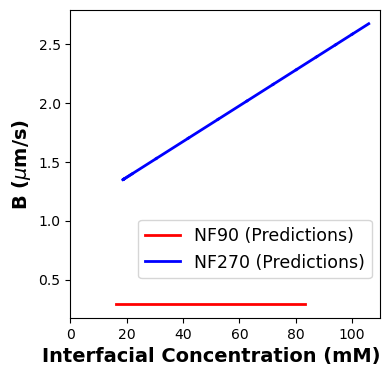

In [ ]:
fig = plt.figure(figsize=(4,4))

# simulated NF90
cIn0 = 16.17231759780746
cInf = 83.16774021880602
B90 = data_stru90['data_config']["B0"]
plt.plot([cIn0,cInf],[B90,B90],'r-',linewidth=2)

for i in range(data_stru270['data_config']['n']):
        plt.plot(sim_stru270[i]["cIn"],sim_stru270[i]["B"],'b-',linewidth=2)

plt.xlabel('Interfacial Concentration (mM)',fontsize=14,fontweight='bold',loc='right')
plt.ylabel('B ($\mu$m/s)',fontsize=14,fontweight='bold')

# ghost point for legend    
plt.plot([],[],'r-',linewidth=2,label='NF90 (Predictions)')
plt.plot([],[],'b-',linewidth=2,label='NF270 (Predictions)')
plt.legend(fontsize=12.5,loc='lower right',bbox_to_anchor=(1, 0.1))
plt.xlim(left=0,right=110)
# plt.ylim(bottom=0,top=110)

plt.show()